Using device: cpu
SimpleDNN(
  (network): Sequential(
    (0): Linear(in_features=7, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=10, bias=True)
  )
)

Starting model training (Baseline DNN)...
Epoch [50/500], Loss: 0.001493
Epoch [100/500], Loss: 0.000590
Epoch [150/500], Loss: 0.000624
Epoch [200/500], Loss: 0.000795
Epoch [250/500], Loss: 0.000576
Epoch [300/500], Loss: 0.000273
Epoch [350/500], Loss: 0.000186
Epoch [400/500], Loss: 0.001310
Epoch [450/500], Loss: 0.001319
Epoch [500/500], Loss: 0.000326
Training complete.

Test MSE Loss (scaled): 0.001507
Mean Relative Error (unscaled): 0.01861895
Mean Accuracy (unscaled): 98.1381 %

--- Mean Relative Error per Mode ---
Mode 1: 0.02331639
Mode 2: 0.01923610
Mode 3: 0.02030662
Mode 4: 0.01629206
Mode 5: 0.01963196
Mode 6: 0.01657090
M

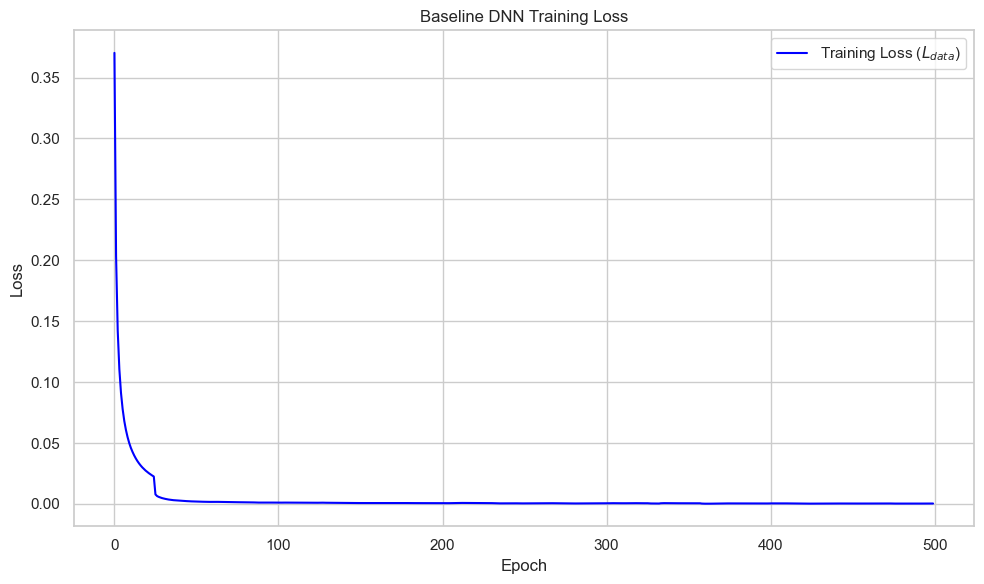

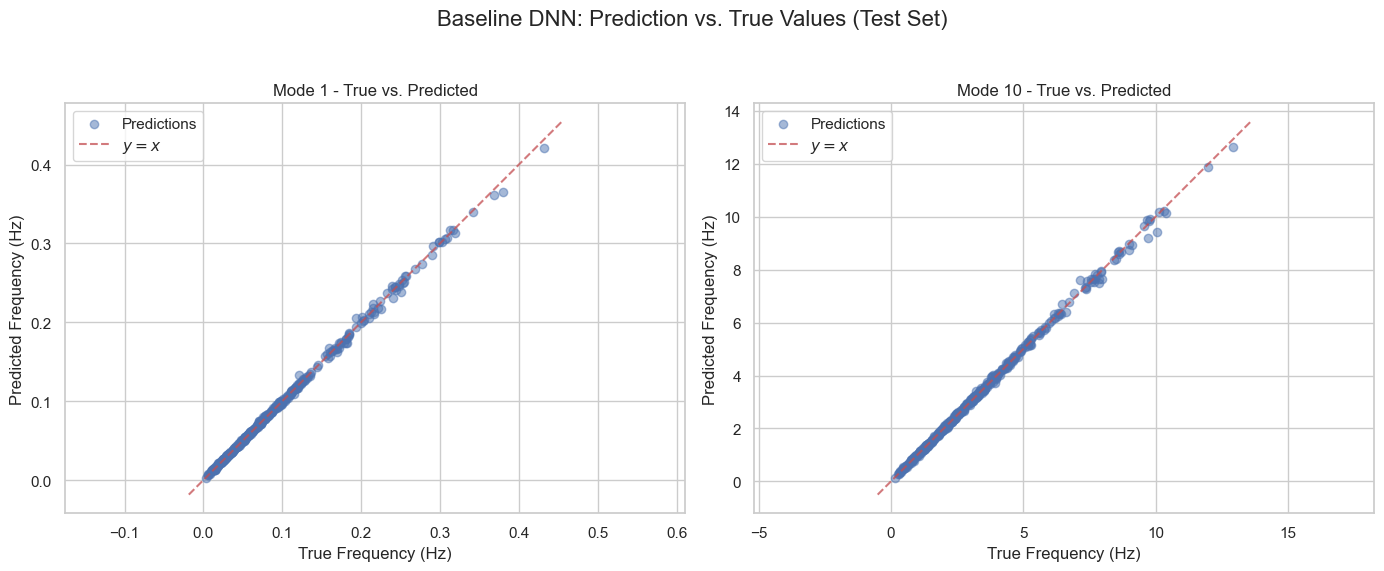

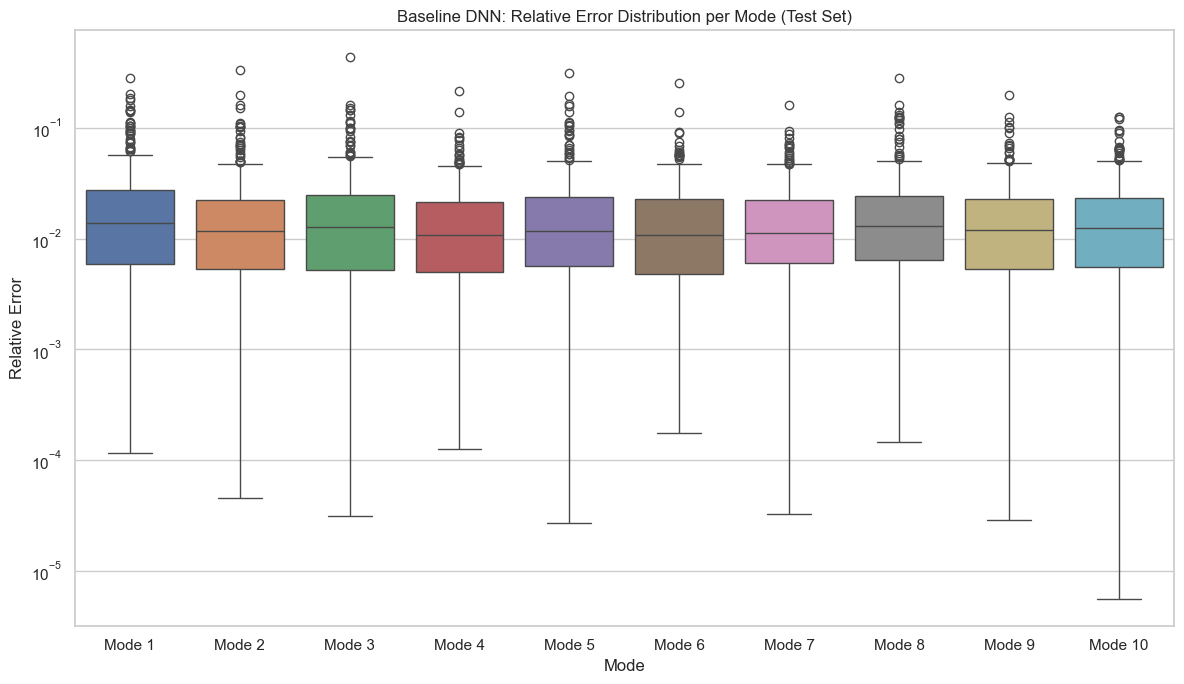

In [1]:
#Baseline DNN
!pip install matplotlib seaborn

# Importing Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import os
import matplotlib.pyplot as plt
import seaborn as sns

#Seeting up Random Seed
seed_value = 42
np.random.seed(seed_value)
torch.manual_seed(seed_value)
os.environ['PYTHONHASHSEED'] = str(seed_value)

#Loading the data
file_path = r"C:\Users\ADMIN\delta_wing_trial11_results.csv" 
try:
    df = pd.read_csv(file_path, sep='\t', encoding='latin1')
except Exception as e:
    print(f"Error loading file: {e}")
    raise e

#Definining Features (X) and Targets (y)
try:
    input_features = df.columns[1:8]
    target_features = df.columns[8:18] 
    X = df[input_features].values
    y = df[target_features].values
except Exception as e:
    print(f"Error selecting columns: {e}")
    raise e

#Split Data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed_value)

# Scale Data
x_scaler = StandardScaler()
y_scaler = StandardScaler()
X_train_scaled = x_scaler.fit_transform(X_train)
y_train_scaled = y_scaler.fit_transform(y_train)
X_test_scaled = x_scaler.transform(X_test)
y_test_scaled = y_scaler.transform(y_test)

#Convert to PyTorch Tensors
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

if device == 'cuda':
    torch.cuda.manual_seed(seed_value)
    torch.cuda.manual_seed_all(seed_value)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32).to(device)

g = torch.Generator()
g.manual_seed(seed_value)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, generator=g)

#Definining the DNN Model
class SimpleDNN(nn.Module):
    def __init__(self, input_size, output_size):
        super(SimpleDNN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, output_size)
        )
    
    def forward(self, x):
        return self.network(x)

model = SimpleDNN(input_size=X_train.shape[1], output_size=y_train.shape[1]).to(device)
print(model)

#7. Define Loss, Optimizer, and Training Loop
criterion = nn.MSELoss()  # Mean Squared Error
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 500

# List to store loss history for plotting
loss_history = []

print("\nStarting model training (Baseline DNN)...")

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_loss)
    
    if (epoch + 1) % 50 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.6f}')

print("Training complete.")

#Evaluating the Model
model.eval()
with torch.no_grad():
    y_pred_scaled = model(X_test_tensor)
    test_loss = criterion(y_pred_scaled, y_test_tensor)
    print(f"\nTest MSE Loss (scaled): {test_loss.item():.6f}")
    
    #Calculate Relative Error
    y_pred_unscaled = y_scaler.inverse_transform(y_pred_scaled.cpu().numpy())
    
    epsilon = 1e-10
    relative_error = np.abs((y_test - y_pred_unscaled) / (y_test + epsilon))
    mean_relative_error = np.mean(relative_error)
    
    #PRINT ACCURACY IN PERCENTAGE
    mean_accuracy = (1.0 - mean_relative_error) * 100
    print(f"Mean Relative Error (unscaled): {mean_relative_error:.8f}")
    print(f"Mean Accuracy (unscaled): {mean_accuracy:.4f} %")
    
    mean_relative_error_per_mode = np.mean(relative_error, axis=0)
    print("\n--- Mean Relative Error per Mode ---")
    for i, err in enumerate(mean_relative_error_per_mode):
        print(f"Mode {i+1}: {err:.8f}")

#9. Generate and Save Plots
print("\nGenerating and saving plots...")

# Set style
sns.set(style="whitegrid")

# Plot 1: Training Loss Curve
plt.figure(figsize=(10, 6))

# 1. Convert loss history to a pandas Series
loss_series = pd.Series(loss_history)
# 2. Calculate the rolling mean (e.g., over a window of 25 epochs)
window_size = 25
loss_smooth = loss_series.rolling(window_size, min_periods=1).mean()

# 3. Plot ONLY the smoothed data
plt.plot(loss_smooth, label='Training Loss ($L_{data}$)', color='blue')

plt.title('Baseline DNN Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss') 
# plt.yscale('log') 
plt.legend()
plt.tight_layout()
plt.savefig('dnn_loss_curve.png')
print("Saved dnn_loss_curve.png")

# Plot 2: Prediction vs. True Values
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot for Mode 1
ax1.scatter(y_test[:, 0], y_pred_unscaled[:, 0], alpha=0.5, label='Predictions')
lims1 = [
    np.min([ax1.get_xlim(), ax1.get_ylim()]),
    np.max([ax1.get_xlim(), ax1.get_ylim()]),
]
ax1.plot(lims1, lims1, 'r--', alpha=0.75, label='$y=x$')
ax1.set_xlabel('True Frequency (Hz)')
ax1.set_ylabel('Predicted Frequency (Hz)')
ax1.set_title('Mode 1 - True vs. Predicted')
ax1.legend()
ax1.axis('equal')

# Plot for Mode 10
ax2.scatter(y_test[:, -1], y_pred_unscaled[:, -1], alpha=0.5, label='Predictions')
lims2 = [
    np.min([ax2.get_xlim(), ax2.get_ylim()]),
    np.max([ax2.get_xlim(), ax2.get_ylim()]),
]
ax2.plot(lims2, lims2, 'r--', alpha=0.75, label='$y=x$')
ax2.set_xlabel('True Frequency (Hz)')
ax2.set_ylabel('Predicted Frequency (Hz)')
ax2.set_title('Mode 10 - True vs. Predicted')
ax2.legend()
ax2.axis('equal')

fig.suptitle('Baseline DNN: Prediction vs. True Values (Test Set)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('dnn_predictions.png')
print("Saved dnn_predictions.png")

# Plot 3: Relative Error Distribution
plt.figure(figsize=(12, 7))
# Convert the (N_test, 10) error array to a DataFrame for easier plotting
error_df = pd.DataFrame(relative_error, columns=[f'Mode {i+1}' for i in range(10)])
sns.boxplot(data=error_df)
plt.title('Baseline DNN: Relative Error Distribution per Mode (Test Set)')
plt.ylabel('Relative Error')
plt.xlabel('Mode')
plt.yscale('log') # Use log scale to see the distribution better
plt.tight_layout()
plt.savefig('dnn_errors.png')
print("Saved dnn_errors.png")

print("\nAll tasks complete.")

Using device: cpu
SimpleDNN(
  (network): Sequential(
    (0): Linear(in_features=7, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=10, bias=True)
  )
)

--- Part 1: Training with ADAM for 500 epochs ---
Epoch [50/500], Loss: 0.002347 (Data: 0.001402, Phys (Raw): 0.062967)
Epoch [100/500], Loss: 0.001577 (Data: 0.000614, Phys (Raw): 0.064197)
Epoch [150/500], Loss: 0.002245 (Data: 0.001282, Phys (Raw): 0.064228)
Epoch [200/500], Loss: 0.001487 (Data: 0.000526, Phys (Raw): 0.064088)
Epoch [250/500], Loss: 0.003506 (Data: 0.002554, Phys (Raw): 0.063444)
Epoch [300/500], Loss: 0.001239 (Data: 0.000276, Phys (Raw): 0.064224)
Epoch [350/500], Loss: 0.001178 (Data: 0.000215, Phys (Raw): 0.064172)
Epoch [400/500], Loss: 0.001441 (Data: 0.000475, Phys (Raw): 0.064404)
Epoch [450/500], Loss: 0.0014

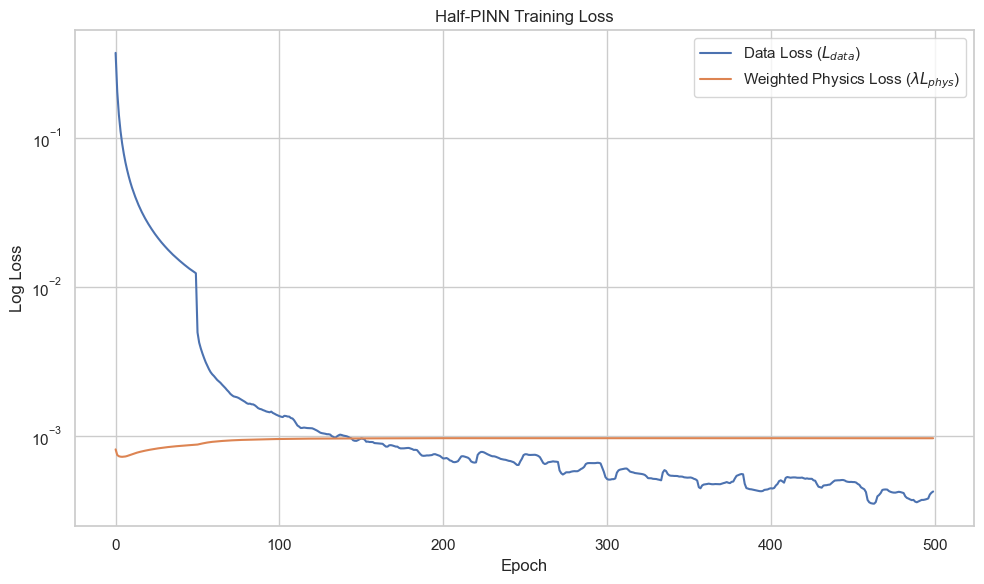

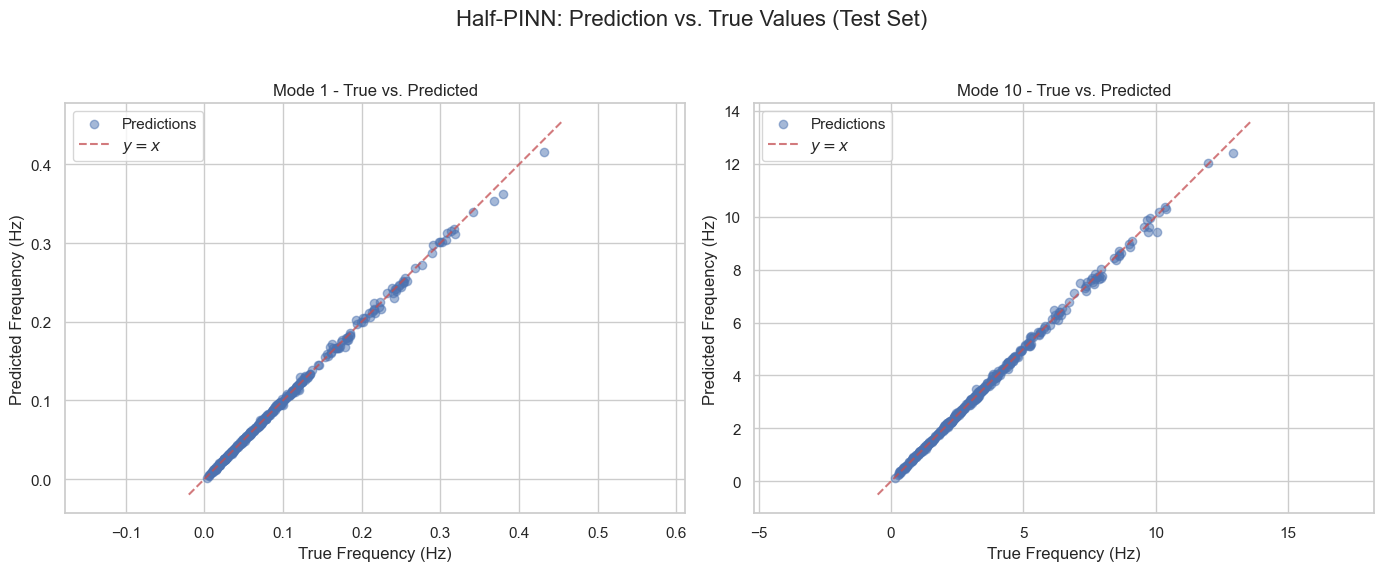

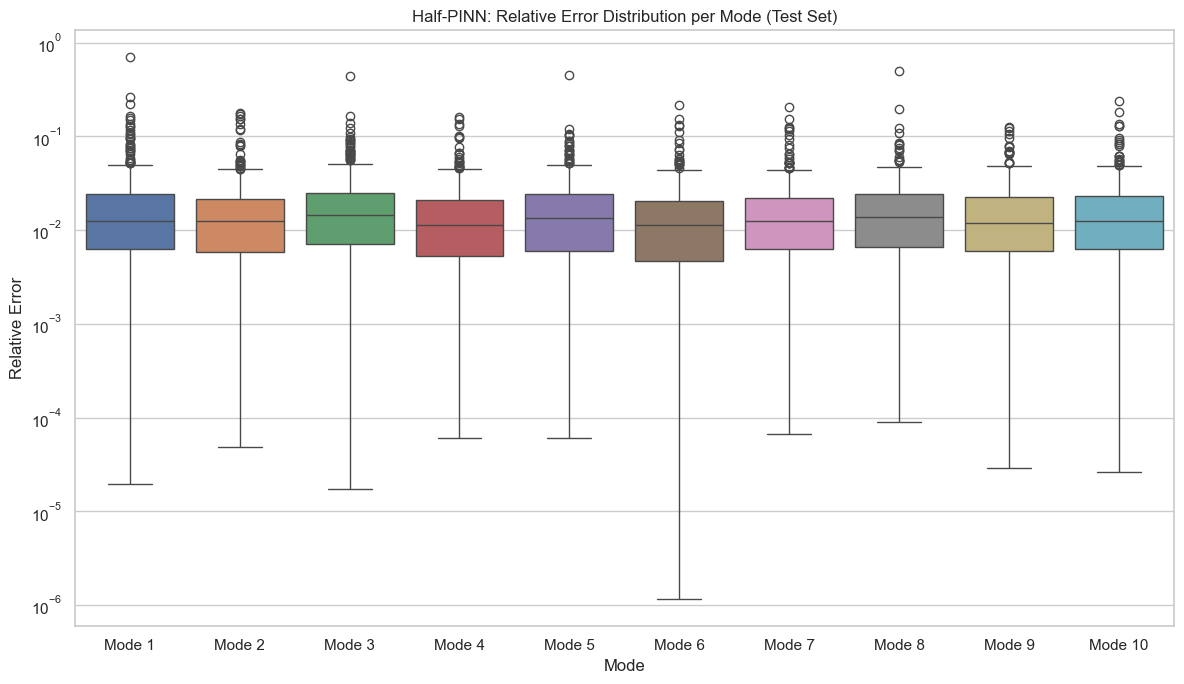

In [7]:
# (Polished): Half-PINN (ADAM + L-BFGS)

#Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import os
import matplotlib.pyplot as plt
import seaborn as sns

#Set Random Seed
seed_value = 42
np.random.seed(seed_value)
torch.manual_seed(seed_value)
os.environ['PYTHONHASHSEED'] = str(seed_value)

#Load Data (with encoding fix)
file_path = r"C:\Users\ADMIN\delta_wing_trial11_results.csv" 
try:
    df = pd.read_csv(file_path, sep='\t', encoding='latin1')
except Exception as e:
    print(f"Error loading file: {e}")
    raise e

#Define Features (X) and Targets (y)
try:
    input_features = df.columns[1:8]
    target_features = df.columns[8:18] 
    X = df[input_features].values
    y = df[target_features].values
except Exception as e:
    print(f"Error selecting columns: {e}")
    raise e

#Split Data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed_value)

#Scale Data
x_scaler = StandardScaler()
y_scaler = StandardScaler()
X_train_scaled = x_scaler.fit_transform(X_train)
y_train_scaled = y_scaler.fit_transform(y_train)
X_test_scaled = x_scaler.transform(X_test)
y_test_scaled = y_scaler.transform(y_test)

#Convert to PyTorch Tensors
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

if device == 'cuda':
    torch.cuda.manual_seed(seed_value)
    torch.cuda.manual_seed_all(seed_value)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32).to(device)

g = torch.Generator()
g.manual_seed(seed_value)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, generator=g)

#Define the Simple DNN Model
class SimpleDNN(nn.Module):
    def __init__(self, input_size, output_size):
        super(SimpleDNN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, output_size)
        )
    
    def forward(self, x):
        return self.network(x)

model = SimpleDNN(input_size=X_train.shape[1], output_size=y_train.shape[1]).to(device)
print(model)

#Define Loss and Optimizers
criterion = nn.MSELoss()  # L_data
lambda_phys = 0.01
num_epochs_adam = 500

#PART 1: Training with ADAM
print(f"\n--- Part 1: Training with ADAM for {num_epochs_adam} epochs ---")
optimizer_adam = optim.Adam(model.parameters(), lr=1e-3)
data_loss_history = []
phys_loss_history = [] #This will now store the WEIGHTED loss

for epoch in range(num_epochs_adam):
    model.train()
    epoch_data_loss = 0
    epoch_phys_loss = 0 #This will track the raw phys loss for the epoch
    
    for X_batch, y_batch in train_loader:
        y_pred_scaled = model(X_batch)
        
        loss_data = criterion(y_pred_scaled, y_batch)
        diffs = y_pred_scaled[:, :-1] - y_pred_scaled[:, 1:]
        violations = torch.relu(diffs)
        loss_phys = torch.mean(violations) #This is the raw physics loss
        
        loss_total = loss_data + lambda_phys * loss_phys
        
        optimizer_adam.zero_grad()
        loss_total.backward()
        optimizer_adam.step()
        
        epoch_data_loss += loss_data.item()
        epoch_phys_loss += loss_phys.item() 
    
    avg_data_loss = epoch_data_loss / len(train_loader)
    avg_phys_loss = epoch_phys_loss / len(train_loader)
    
    data_loss_history.append(avg_data_loss)
    phys_loss_history.append(lambda_phys * avg_phys_loss) 

    if (epoch + 1) % 50 == 0:
        avg_total_loss = avg_data_loss + (lambda_phys * avg_phys_loss)
        print(f'Epoch [{epoch+1}/{num_epochs_adam}], Loss: {avg_total_loss:.6f} '
              f'(Data: {avg_data_loss:.6f}, Phys (Raw): {avg_phys_loss:.6f})')

print("ADAM training complete.")


# PART 2: Fine-Tuning with L-BFGS
print("\n--- Part 2: Fine-Tuning with L-BFGS ---")
optimizer_lbfgs = optim.LBFGS(model.parameters(), lr=0.1, max_iter=50)

def closure():
    optimizer_lbfgs.zero_grad()
    
    y_pred_scaled = model(X_train_tensor)
    
    loss_data = criterion(y_pred_scaled, y_train_tensor)
    diffs = y_pred_scaled[:, :-1] - y_pred_scaled[:, 1:]
    violations = torch.relu(diffs)
    loss_phys = torch.mean(violations) # Raw physics loss
    loss_total = loss_data + lambda_phys * loss_phys
    
    loss_total.backward()
    
    print(f'L-BFGS Step -> Total Loss: {loss_total.item():.8f} '
          f'(Data: {loss_data.item():.8f}, Phys (Raw): {loss_phys.item():.8f})')
    
    return loss_total

model.train()
optimizer_lbfgs.step(closure)

print("L-BFGS fine-tuning complete.")

#Evaluate the Final, Polished Model\
print("\n--- Final Model Evaluation ---")
model.eval()
with torch.no_grad():
    y_pred_scaled = model(X_test_tensor)
    test_loss = criterion(y_pred_scaled, y_test_tensor)
    print(f"\nTest MSE Loss (scaled): {test_loss.item():.6f}")
    
    y_pred_unscaled = y_scaler.inverse_transform(y_pred_scaled.cpu().numpy())
    
    epsilon = 1e-10
    relative_error = np.abs((y_test - y_pred_unscaled) / (y_test + epsilon))
    mean_relative_error = np.mean(relative_error)
    
    mean_accuracy = (1.0 - mean_relative_error) * 100
    print(f"Mean Relative Error (unscaled): {mean_relative_error:.8f}")
    print(f"Mean Accuracy (unscaled): {mean_accuracy:.4f} %")
    
    mean_relative_error_per_mode = np.mean(relative_error, axis=0)
    print("\n--- Mean Relative Error per Mode ---")
    for i, err in enumerate(mean_relative_error_per_mode):
        print(f"Mode {i+1}: {err:.8f}")

    print("\n--- Checking for Order Violations in Test Set ---")
    diffs_unscaled = y_pred_unscaled[:, :-1] - y_pred_unscaled[:, 1:]
    violations = np.sum(diffs_unscaled > 0)
    total_comparisons = diffs_unscaled.size
    
    print(f"Total order violations (f_i > f_i+1) in test set: {violations} / {total_comparisons}")

#Generate and Save Plots
print("\nGenerating and saving plots...")
sns.set(style="whitegrid")

#Plot 1: Training Loss Curve (SMOOTHED and CORRECTED)
plt.figure(figsize=(10, 6))

window_size = 50 

 
# 1. Data Loss
data_loss_series = pd.Series(data_loss_history)
data_smooth = data_loss_series.rolling(window_size, min_periods=1).mean()
# 2. (Weighted) Physics Loss
phys_loss_series = pd.Series(phys_loss_history)
phys_smooth = phys_loss_series.rolling(window_size, min_periods=1).mean()

# 3. Plot the smoothed, comparable curves
plt.plot(data_smooth, label='Data Loss ($L_{data}$)')
plt.plot(phys_smooth, label='Weighted Physics Loss ($\lambda L_{phys}$)') 

plt.title('Half-PINN Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Log Loss')
plt.yscale('log')
plt.legend()
plt.tight_layout()
plt.savefig('half_pinn_loss_curve.png') 
print("Saved half_pinn_loss_curve.png")

# Plot 2: Prediction vs. True Values
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot for Mode 1
ax1.scatter(y_test[:, 0], y_pred_unscaled[:, 0], alpha=0.5, label='Predictions')
lims1 = [
    np.min([ax1.get_xlim(), ax1.get_ylim()]),
    np.max([ax1.get_xlim(), ax1.get_ylim()]),
]
ax1.plot(lims1, lims1, 'r--', alpha=0.75, label='$y=x$')
ax1.set_xlabel('True Frequency (Hz)')
ax1.set_ylabel('Predicted Frequency (Hz)')
ax1.set_title('Mode 1 - True vs. Predicted')
ax1.legend()
ax1.axis('equal')

# Plot for Mode 10
ax2.scatter(y_test[:, -1], y_pred_unscaled[:, -1], alpha=0.5, label='Predictions')
lims2 = [
    np.min([ax2.get_xlim(), ax2.get_ylim()]),
    np.max([ax2.get_xlim(), ax2.get_ylim()]),
]
ax2.plot(lims2, lims2, 'r--', alpha=0.75, label='$y=x$')
ax2.set_xlabel('True Frequency (Hz)')
ax2.set_ylabel('Predicted Frequency (Hz)')
ax2.set_title('Mode 10 - True vs. Predicted')
ax2.legend()
ax2.axis('equal')

fig.suptitle('Half-PINN: Prediction vs. True Values (Test Set)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('half_pinn_predictions.png') 
print("Saved half_pinn_predictions.png")

#Plot 3: Relative Error Distribution
plt.figure(figsize=(12, 7))
error_df = pd.DataFrame(relative_error, columns=[f'Mode {i+1}' for i in range(10)])
sns.boxplot(data=error_df)
plt.title('Half-PINN: Relative Error Distribution per Mode (Test Set)')
plt.ylabel('Relative Error')
plt.xlabel('Mode')
plt.yscale('log')
plt.tight_layout()
plt.savefig('half_pinn_errors.png') 
print("Saved half_pinn_errors.png")

print("\nAll tasks complete.")

Using device: cpu
EnhancedDNN(
  (network): Sequential(
    (0): Linear(in_features=7, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=256, bias=True)
    (7): ReLU()
    (8): Linear(in_features=256, out_features=256, bias=True)
    (9): ReLU()
    (10): Linear(in_features=256, out_features=10, bias=True)
  )
)

--- Part 1: Training with ADAM for 500 epochs ---
Epoch [50/500], Loss: 0.002551 (Data: 0.001905, Phys (Raw): 0.064631)
Epoch [100/500], Loss: 0.005323 (Data: 0.004674, Phys (Raw): 0.064906)
Epoch [150/500], Loss: 0.001542 (Data: 0.000883, Phys (Raw): 0.065912)
Epoch [200/500], Loss: 0.001291 (Data: 0.000633, Phys (Raw): 0.065725)
Epoch [250/500], Loss: 0.003579 (Data: 0.002927, Phys (Raw): 0.065267)
Epoch [300/500], Loss: 0.000908 (Data: 0.000249, Phys (Raw): 0.065896)
Epoch [350/5

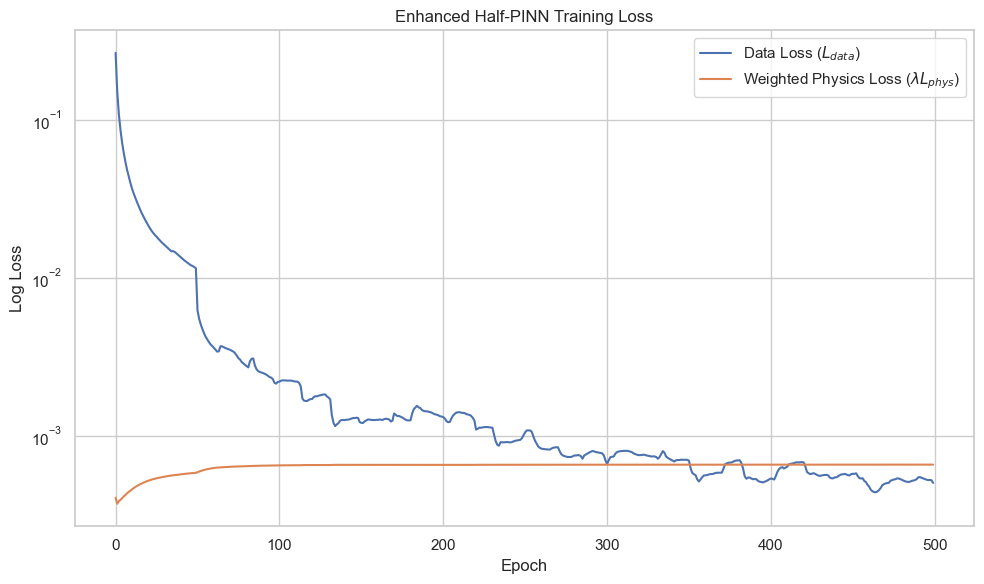

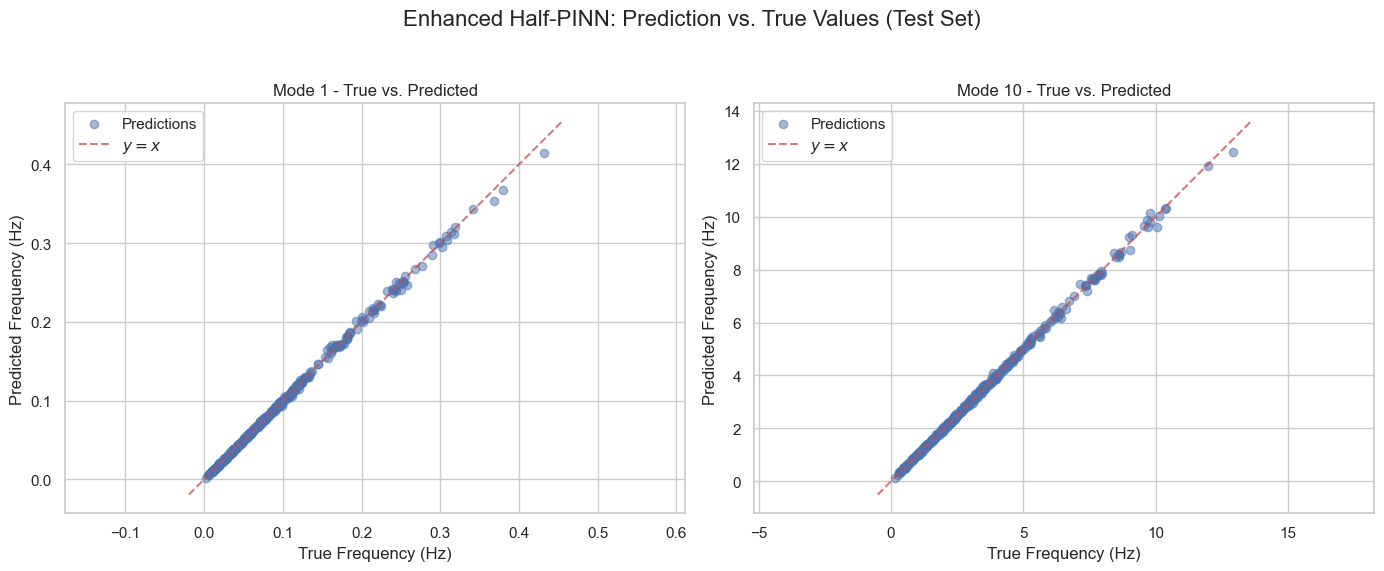

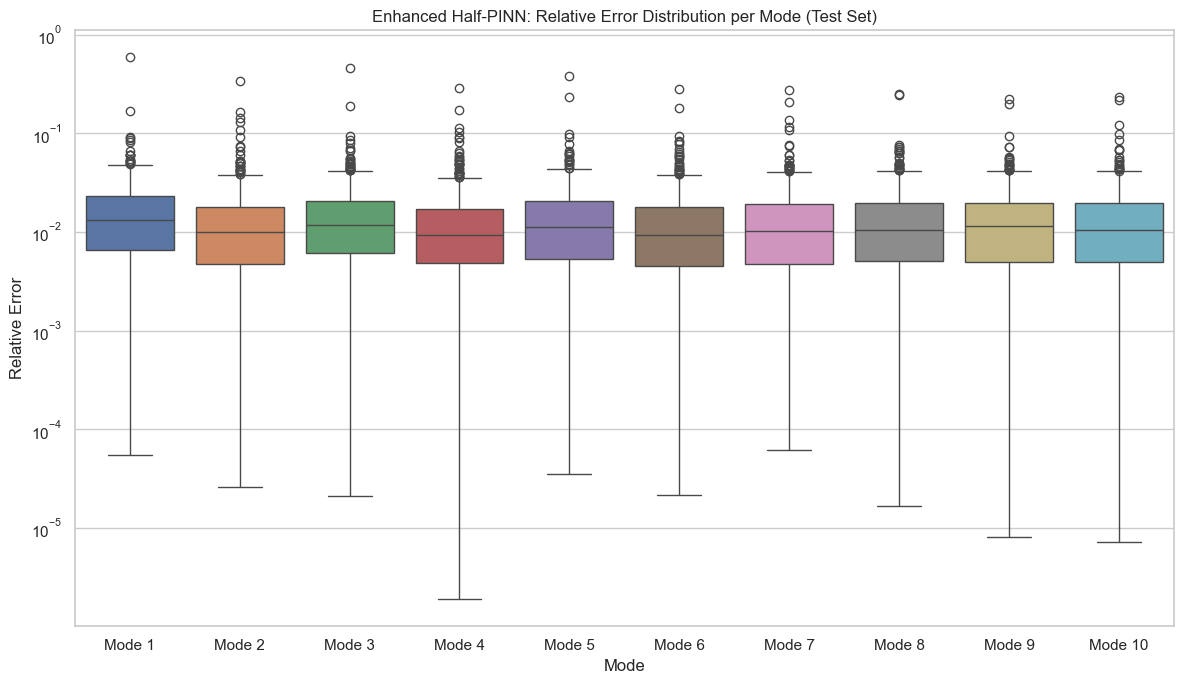

In [8]:
# !pip install matplotlib seaborn

# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import os
import matplotlib.pyplot as plt
import seaborn as sns

# --- Set Random Seed---
seed_value = 42
np.random.seed(seed_value)
torch.manual_seed(seed_value)
os.environ['PYTHONHASHSEED'] = str(seed_value)

# --- 1. Load Data (with encoding fix) ---
file_path = r"C:\Users\ADMIN\delta_wing_trial11_results.csv" 
try:
    df = pd.read_csv(file_path, sep='\t', encoding='latin1')
except Exception as e:
    print(f"Error loading file: {e}")
    raise e

# --- 2. Define Features (X) and Targets (y) ---
try:
    input_features = df.columns[1:8]
    target_features = df.columns[8:18] 
    X = df[input_features].values
    y = df[target_features].values
except Exception as e:
    print(f"Error selecting columns: {e}")
    raise e

# --- 3. Split Data (80% train, 20% test) ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed_value)

# --- 4. Scale Data ---
x_scaler = StandardScaler()
y_scaler = StandardScaler()
X_train_scaled = x_scaler.fit_transform(X_train)
y_train_scaled = y_scaler.fit_transform(y_train)
X_test_scaled = x_scaler.transform(X_test)
y_test_scaled = y_scaler.transform(y_test)

# --- 5. Convert to PyTorch Tensors ---
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

if device == 'cuda':
    torch.cuda.manual_seed(seed_value)
    torch.cuda.manual_seed_all(seed_value)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32).to(device)

g = torch.Generator()
g.manual_seed(seed_value)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, generator=g)

# --- 6. Define the DNN Model (Increased Capacity for better data fit) ---
class EnhancedDNN(nn.Module):
    def __init__(self, input_size, output_size):
        super(EnhancedDNN, self).__init__()
        # Increased width to 256 and depth to 5 hidden layers (7 total layers)
        hidden_size = 256 
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, output_size)
        )
    
    def forward(self, x):
        return self.network(x)

model = EnhancedDNN(input_size=X_train.shape[1], output_size=y_train.shape[1]).to(device)
print(model)

# --- 7. Define Loss and Optimizers ---
criterion = nn.MSELoss()  # L_data
# Optimal value found through testing
lambda_phys = 0.01 
num_epochs_adam = 500

# --- PART 1: Training with ADAM ---
print(f"\n--- Part 1: Training with ADAM for {num_epochs_adam} epochs ---")
optimizer_adam = optim.Adam(model.parameters(), lr=1e-3)
data_loss_history = []
phys_loss_history = [] # This will now store the WEIGHTED loss

for epoch in range(num_epochs_adam):
    model.train()
    epoch_data_loss = 0
    epoch_phys_loss = 0 # This will track the raw phys loss for the epoch
    
    for X_batch, y_batch in train_loader:
        y_pred_scaled = model(X_batch)
        
        # Data Loss (L_data)
        loss_data = criterion(y_pred_scaled, y_batch)
        
        # Physics Loss (L_phys): Enforce Monotonic Order (f_i <= f_i+1)
        diffs = y_pred_scaled[:, :-1] - y_pred_scaled[:, 1:]
        violations = torch.relu(diffs)
        loss_phys = torch.mean(violations) # This is the raw physics loss
        
        # Total Loss
        loss_total = loss_data + lambda_phys * loss_phys
        
        optimizer_adam.zero_grad()
        loss_total.backward()
        optimizer_adam.step()
        
        epoch_data_loss += loss_data.item()
        epoch_phys_loss += loss_phys.item() 
    
    avg_data_loss = epoch_data_loss / len(train_loader)
    avg_phys_loss = epoch_phys_loss / len(train_loader)
    
    data_loss_history.append(avg_data_loss)
    phys_loss_history.append(lambda_phys * avg_phys_loss) 

    if (epoch + 1) % 50 == 0:
        avg_total_loss = avg_data_loss + (lambda_phys * avg_phys_loss)
        print(f'Epoch [{epoch+1}/{num_epochs_adam}], Loss: {avg_total_loss:.6f} '
              f'(Data: {avg_data_loss:.6f}, Phys (Raw): {avg_phys_loss:.6f})')

print("ADAM training complete.")


# --- PART 2: Fine-Tuning with L-BFGS (using the whole training set) ---
print("\n--- Part 2: Fine-Tuning with L-BFGS ---")
optimizer_lbfgs = optim.LBFGS(model.parameters(), lr=0.1, max_iter=50)

def closure():
    optimizer_lbfgs.zero_grad()
    
    # Use the entire training set for L-BFGS
    y_pred_scaled = model(X_train_tensor)
    
    # Recalculate losses
    loss_data = criterion(y_pred_scaled, y_train_tensor)
    diffs = y_pred_scaled[:, :-1] - y_pred_scaled[:, 1:]
    violations = torch.relu(diffs)
    loss_phys = torch.mean(violations) # Raw physics loss
    loss_total = loss_data + lambda_phys * loss_phys
    
    loss_total.backward()
    
    print(f'L-BFGS Step -> Total Loss: {loss_total.item():.8f} '
          f'(Data: {loss_data.item():.8f}, Phys (Raw): {loss_phys.item():.8f})')
    
    return loss_total

model.train()
optimizer_lbfgs.step(closure)

print("L-BFGS fine-tuning complete.")

# --- 8. Evaluate the Final, Polished Model ---
print("\n--- Final Model Evaluation ---")
model.eval()
with torch.no_grad():
    y_pred_scaled = model(X_test_tensor)
    test_loss = criterion(y_pred_scaled, y_test_tensor)
    print(f"\nTest MSE Loss (scaled): {test_loss.item():.6f}")
    
    # Inverse transform predictions for evaluation
    y_pred_unscaled = y_scaler.inverse_transform(y_pred_scaled.cpu().numpy())
    
    epsilon = 1e-10
    # Calculate Relative Error
    relative_error = np.abs((y_test - y_pred_unscaled) / (y_test + epsilon))
    mean_relative_error = np.mean(relative_error)
    
    # PRINT ACCURACY IN PERCENTAGE
    mean_accuracy = (1.0 - mean_relative_error) * 100
    print(f"Mean Relative Error (unscaled): {mean_relative_error:.8f}")
    print(f"Mean Accuracy (unscaled): {mean_accuracy:.4f} %")
    
    mean_relative_error_per_mode = np.mean(relative_error, axis=0)
    print("\n--- Mean Relative Error per Mode ---")
    for i, err in enumerate(mean_relative_error_per_mode):
        print(f"Mode {i+1}: {err:.8f}")

    print("\n--- Checking for Order Violations in Test Set ---")
    # A violation is when f_i > f_i+1
    diffs_unscaled = y_pred_unscaled[:, :-1] - y_pred_unscaled[:, 1:]
    violations = np.sum(diffs_unscaled > 0)
    total_comparisons = diffs_unscaled.size
    
    print(f"Total order violations (f_i > f_i+1) in test set: {violations} / {total_comparisons}")

# --- 9. Generate and Save Plots ---
print("\nGenerating and saving plots...")
sns.set(style="whitegrid")

# --- Plot 1: Training Loss Curve (SMOOTHED) ---
plt.figure(figsize=(10, 6))
window_size = 50 
 
# 1. Data Loss
data_loss_series = pd.Series(data_loss_history)
data_smooth = data_loss_series.rolling(window_size, min_periods=1).mean()
# 2. (Weighted) Physics Loss
phys_loss_series = pd.Series(phys_loss_history)
phys_smooth = phys_loss_series.rolling(window_size, min_periods=1).mean()

# 3. Plot the smoothed, comparable curves
plt.plot(data_smooth, label='Data Loss ($L_{data}$)')
plt.plot(phys_smooth, label='Weighted Physics Loss ($\lambda L_{phys}$)') 

plt.title('Enhanced Half-PINN Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Log Loss')
plt.yscale('log')
plt.legend()
plt.tight_layout()
plt.savefig('enhanced_half_pinn_loss_curve.png') 
print("Saved enhanced_half_pinn_loss_curve.png")

# --- Plot 2: Prediction vs. True Values ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot for Mode 1
ax1.scatter(y_test[:, 0], y_pred_unscaled[:, 0], alpha=0.5, label='Predictions')
lims1 = [
    np.min([ax1.get_xlim(), ax1.get_ylim()]),
    np.max([ax1.get_xlim(), ax1.get_ylim()]),
]
ax1.plot(lims1, lims1, 'r--', alpha=0.75, label='$y=x$')
ax1.set_xlabel('True Frequency (Hz)')
ax1.set_ylabel('Predicted Frequency (Hz)')
ax1.set_title('Mode 1 - True vs. Predicted')
ax1.legend()
ax1.axis('equal')

# Plot for Mode 10
ax2.scatter(y_test[:, -1], y_pred_unscaled[:, -1], alpha=0.5, label='Predictions')
lims2 = [
    np.min([ax2.get_xlim(), ax2.get_ylim()]),
    np.max([ax2.get_xlim(), ax2.get_ylim()]),
]
ax2.plot(lims2, lims2, 'r--', alpha=0.75, label='$y=x$')
ax2.set_xlabel('True Frequency (Hz)')
ax2.set_ylabel('Predicted Frequency (Hz)')
ax2.set_title('Mode 10 - True vs. Predicted')
ax2.legend()
ax2.axis('equal')

fig.suptitle('Enhanced Half-PINN: Prediction vs. True Values (Test Set)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('enhanced_half_pinn_predictions.png') 
print("Saved enhanced_half_pinn_predictions.png")

# --- Plot 3: Relative Error Distribution ---
plt.figure(figsize=(12, 7))
error_df = pd.DataFrame(relative_error, columns=[f'Mode {i+1}' for i in range(10)])
sns.boxplot(data=error_df)
plt.title('Enhanced Half-PINN: Relative Error Distribution per Mode (Test Set)')
plt.ylabel('Relative Error')
plt.xlabel('Mode')
plt.yscale('log')
plt.tight_layout()
plt.savefig('enhanced_half_pinn_errors.png') 
print("Saved enhanced_half_pinn_errors.png")

print("\nAll tasks complete.")

Training samples: 1653
Testing samples: 414
Using device: cpu
HybridPINN(
  (base_network): Sequential(
    (0): Linear(in_features=7, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=10, bias=True)
  )
)

--- Part 1: Training with ADAM for 1000 epochs ---
Epoch [50/1000], Loss: 0.003340 (Data: 0.003340, Phys: 0.000013)
Epoch [100/1000], Loss: 0.001437 (Data: 0.001437, Phys: 0.000009)
Epoch [150/1000], Loss: 0.000966 (Data: 0.000966, Phys: 0.000007)
Epoch [200/1000], Loss: 0.003332 (Data: 0.003332, Phys: 0.000019)
Epoch [250/1000], Loss: 0.002838 (Data: 0.002838, Phys: 0.000018)
Epoch [300/1000], Loss: 0.000337 (Data: 0.000337, Phys: 0.000001)
Epoch [350/1000], Loss: 0.000278 (Data: 0.000278, Phys: 0.000002)
Epoch [400/1000], Loss: 0.000279 (Data: 0.000279, Phys: 0.000000)
Epoch [450/1000], 

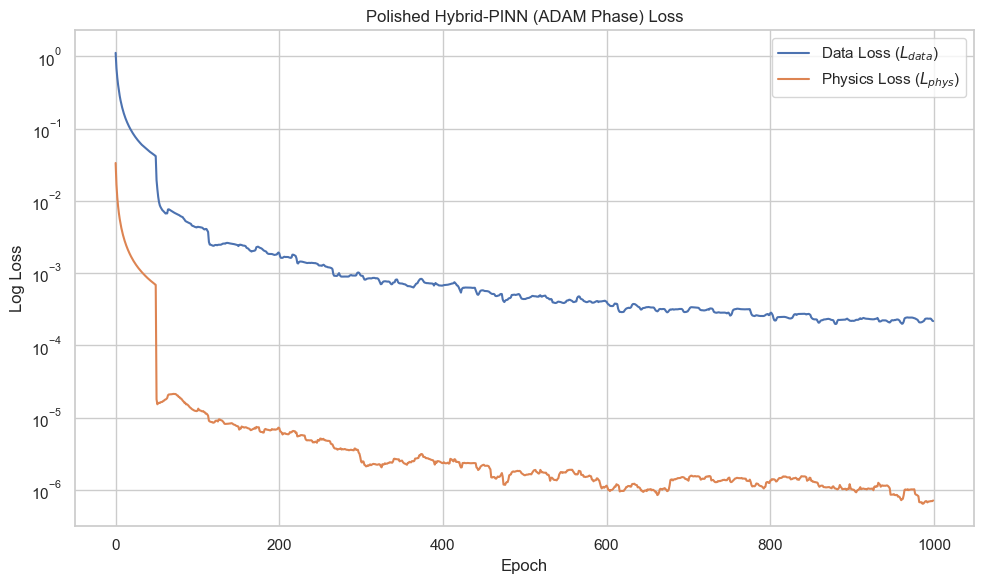

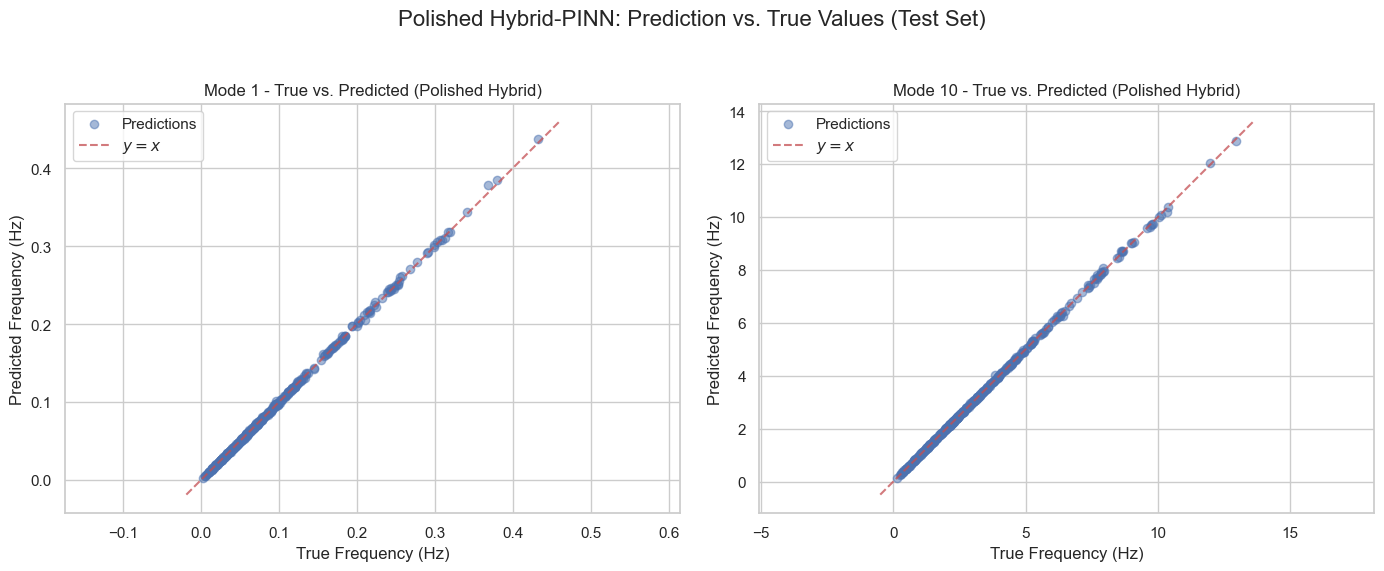

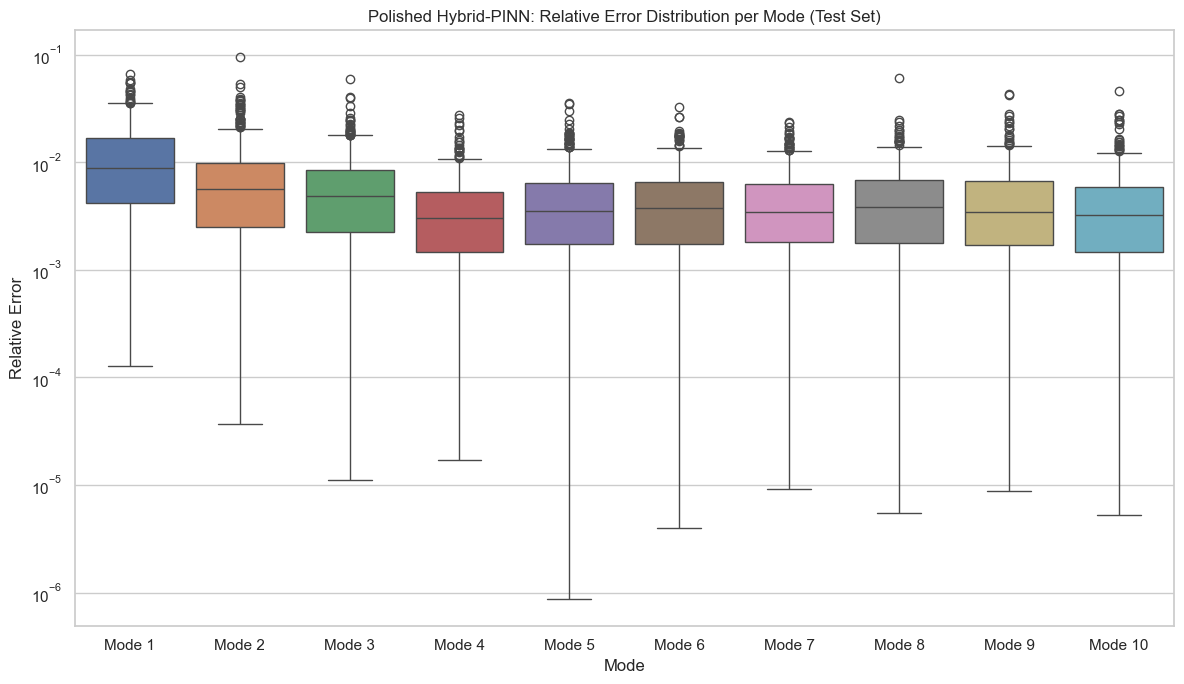

In [1]:
# (Polished): Hybrid-PINN (ADAM + L-BFGS) ---

# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import os
import matplotlib.pyplot as plt
import seaborn as sns

# --- Set Random Seed ---
seed_value = 42
np.random.seed(seed_value)
torch.manual_seed(seed_value)
os.environ['PYTHONHASHSEED'] = str(seed_value)

# --- 1. Load Data (with encoding fix) ---
file_path = r"C:\Users\ADMIN\delta_wing_trial11_results.csv" 
try:
    df = pd.read_csv(file_path, sep='\t', encoding='latin1')
except Exception as e:
    print(f"Error loading file: {e}")
    raise e

# --- 2. Define Features (X) and Targets (y) ---
try:
    input_features_df = df.columns[1:8]
    target_features_df = df.columns[8:18] 
    X = df[input_features_df].values
    y = df[target_features_df].values
except Exception as e:
    print(f"Error selecting columns: {e}")
    raise e

# --- 3. Split Data (80% train, 20% test) ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed_value)

# --- 4. Scale Data ---
x_scaler = StandardScaler()
X_train_scaled = x_scaler.fit_transform(X_train)
X_test_scaled = x_scaler.transform(X_test)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

# --- 5. Convert to PyTorch Tensors ---
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

if device == 'cuda':
    torch.cuda.manual_seed(seed_value)
    torch.cuda.manual_seed_all(seed_value)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

X_train_tensor_scaled = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
X_test_tensor_scaled = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
y_train_tensor_unscaled = torch.tensor(y_train, dtype=torch.float32).to(device)
y_test_tensor_unscaled = torch.tensor(y_test, dtype=torch.float32).to(device)
X_train_tensor_unscaled = torch.tensor(X_train, dtype=torch.float32).to(device)
X_test_tensor_unscaled = torch.tensor(X_test, dtype=torch.float32).to(device)

train_dataset = TensorDataset(X_train_tensor_scaled, X_train_tensor_unscaled, y_train_tensor_unscaled)
g = torch.Generator()
g.manual_seed(seed_value)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, generator=g)

# --- 6. Define the "Hybrid-PINN" (Hard-Constraint) Model ---
class HybridPINN(nn.Module):
    def __init__(self, input_size, output_size):
        super(HybridPINN, self).__init__()
        self.base_network = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, output_size)
        )
        self.span_idx = 2
        self.youngs_idx = 3
        self.density_idx = 4
        self.thickness_idx = 6
        
    def forward(self, x_scaled, x_unscaled):
        log_f_bar = self.base_network(x_scaled)
        s = x_unscaled[:, self.span_idx]
        E = x_unscaled[:, self.youngs_idx]
        rho = x_unscaled[:, self.density_idx]
        t = x_unscaled[:, self.thickness_idx]
        epsilon = 1e-10
        P = (t / (s**2 + epsilon)) * torch.sqrt(E / (rho + epsilon))
        P = P.unsqueeze(1)
        f_pred = torch.exp(log_f_bar) * P
        return f_pred

# Initialize the model
model = HybridPINN(input_size=X_train.shape[1], output_size=y_train.shape[1]).to(device)
print(model)

# --- 7. Define Loss, Optimizer, and Training Loop ---
criterion = nn.MSELoss()  # L_data
lambda_phys = 0.01  # Soft constraint
num_epochs_adam = 1000 # Train for longer

# --- PART 1: Training with ADAM ---
print(f"\n--- Part 1: Training with ADAM for {num_epochs_adam} epochs ---")
optimizer_adam = optim.Adam(model.parameters(), lr=1e-3)
data_loss_history = []
phys_loss_history = []

for epoch in range(num_epochs_adam):
    model.train()
    epoch_data_loss = 0
    epoch_phys_loss = 0
    
    for X_batch_scaled, X_batch_unscaled, y_batch_unscaled in train_loader:
        y_pred_unscaled = model(X_batch_scaled, X_batch_unscaled)
        
        loss_data = criterion(y_pred_unscaled, y_batch_unscaled)
        diffs = y_pred_unscaled[:, :-1] - y_pred_unscaled[:, 1:]
        violations = torch.relu(diffs)
        loss_phys = torch.mean(violations)
        loss_total = loss_data + lambda_phys * loss_phys
        
        optimizer_adam.zero_grad()
        loss_total.backward()
        optimizer_adam.step()
        
        epoch_data_loss += loss_data.item()
        epoch_phys_loss += loss_phys.item()
    
    avg_data_loss = epoch_data_loss / len(train_loader)
    avg_phys_loss = epoch_phys_loss / len(train_loader)
    data_loss_history.append(avg_data_loss)
    phys_loss_history.append(avg_phys_loss) # We store the RAW phys loss

    if (epoch + 1) % 50 == 0:
        avg_total_loss = avg_data_loss + (lambda_phys * avg_phys_loss)
        print(f'Epoch [{epoch+1}/{num_epochs_adam}], Loss: {avg_total_loss:.6f} '
              f'(Data: {avg_data_loss:.6f}, Phys: {avg_phys_loss:.6f})')

print("ADAM training complete.")


# --- PART 2: Fine-Tuning with L-BFGS ---
print("\n--- Part 2: Fine-Tuning with L-BFGS ---")
optimizer_lbfgs = optim.LBFGS(model.parameters(), lr=0.1, max_iter=100) # More iterations

# L-BFGS requires a "closure" function
def closure():
    optimizer_lbfgs.zero_grad()
    
    # Forward pass on the *entire* training set
    y_pred_unscaled = model(X_train_tensor_scaled, X_train_tensor_unscaled)
    
    # Calculate losses
    loss_data = criterion(y_pred_unscaled, y_train_tensor_unscaled)
    diffs = y_pred_unscaled[:, :-1] - y_pred_unscaled[:, 1:]
    violations = torch.relu(diffs)
    loss_phys = torch.mean(violations)
    
    # Total loss
    loss_total = loss_data + lambda_phys * loss_phys
    
    # Backward pass
    loss_total.backward()
    
    print(f'L-BFGS Step -> Total Loss: {loss_total.item():.8f} '
          f'(Data: {loss_data.item():.8f}, Phys: {loss_phys.item():.8f})')
    
    return loss_total

# Run the L-BFGS optimizer
model.train()
optimizer_lbfgs.step(closure)

print("L-BFGS fine-tuning complete.")

# --- 8. Evaluate the Final, Polished Model ---
print("\n--- Final Model Evaluation ---")
model.eval()
with torch.no_grad():
    y_pred_unscaled = model(X_test_tensor_scaled, X_test_tensor_unscaled).cpu().numpy()
    
    test_loss = criterion(torch.tensor(y_pred_unscaled), torch.tensor(y_test))
    print(f"\nTest MSE Loss (unscaled): {test_loss.item():.6f}")
    
    epsilon = 1e-10
    relative_error = np.abs((y_test - y_pred_unscaled) / (y_test + epsilon))
    mean_relative_error = np.mean(relative_error)
    
    mean_accuracy = (1.0 - mean_relative_error) * 100
    print(f"Mean Relative Error (unscaled): {mean_relative_error:.8f}")
    print(f"Mean Accuracy (unscaled): {mean_accuracy:.4f} %")
    
    mean_relative_error_per_mode = np.mean(relative_error, axis=0)
    print("\n--- Mean Relative Error per Mode ---")
    for i, err in enumerate(mean_relative_error_per_mode):
        print(f"Mode {i+1}: {err:.8f}")

    print("\n--- Checking for Order Violations in Test Set ---")
    diffs_unscaled = y_pred_unscaled[:, :-1] - y_pred_unscaled[:, 1:]
    violations = np.sum(diffs_unscaled > 0)
    total_comparisons = diffs_unscaled.size
    
    print(f"Total order violations (f_i > f_i+1) in test set: {violations} / {total_comparisons}")

# --- 9. Generate and Save Plots ---
print("\nGenerating and saving plots...")
sns.set(style="whitegrid")

# --- Plot 1: Training Loss Curve ---
plt.figure(figsize=(10, 6))

window_size = 50 
epsilon = 1e-12  

# 1. Data Loss (smooth)
data_loss_series = pd.Series(data_loss_history)
data_smooth = data_loss_series.rolling(window_size, min_periods=1).mean()

# 2. Physics Loss 
phys_loss_series = pd.Series(phys_loss_history)
phys_clipped = phys_loss_series.clip(lower=epsilon) # Prevent log(0) error
phys_smooth = phys_clipped.rolling(window_size, min_periods=1).mean()

# 3. Plot the smoothed and clipped data
plt.plot(data_smooth, label='Data Loss ($L_{data}$)')
plt.plot(phys_smooth, label='Physics Loss ($L_{phys}$)')
# --- END OF CHANGES ---

plt.title('Polished Hybrid-PINN (ADAM Phase) Loss')
plt.xlabel('Epoch')
plt.ylabel('Log Loss')
plt.yscale('log')
plt.legend()
plt.tight_layout()
plt.savefig('hybrid_pinn_polished_loss_curve.png')
print("Saved hybrid_pinn_polished_loss_curve.png")

# --- Plot 2: Prediction vs. True Values ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.scatter(y_test[:, 0], y_pred_unscaled[:, 0], alpha=0.5, label='Predictions')
lims1 = [np.min([ax1.get_xlim(), ax1.get_ylim()]), np.max([ax1.get_xlim(), ax1.get_ylim()])]
ax1.plot(lims1, lims1, 'r--', alpha=0.75, label='$y=x$')
ax1.set_xlabel('True Frequency (Hz)')
ax1.set_ylabel('Predicted Frequency (Hz)')
ax1.set_title('Mode 1 - True vs. Predicted (Polished Hybrid)')
ax1.legend()
ax1.axis('equal')
ax2.scatter(y_test[:, -1], y_pred_unscaled[:, -1], alpha=0.5, label='Predictions')
lims2 = [np.min([ax2.get_xlim(), ax2.get_ylim()]), np.max([ax2.get_xlim(), ax2.get_ylim()])]
ax2.plot(lims2, lims2, 'r--', alpha=0.75, label='$y=x$')
ax2.set_xlabel('True Frequency (Hz)')
ax2.set_ylabel('Predicted Frequency (Hz)')
ax2.set_title('Mode 10 - True vs. Predicted (Polished Hybrid)')
ax2.legend()
ax2.axis('equal')
fig.suptitle('Polished Hybrid-PINN: Prediction vs. True Values (Test Set)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('hybrid_pinn_polished_predictions.png')
print("Saved hybrid_pinn_polished_predictions.png")

# --- Plot 3: Relative Error Distribution ---
plt.figure(figsize=(12, 7))
error_df = pd.DataFrame(relative_error, columns=[f'Mode {i+1}' for i in range(10)])
sns.boxplot(data=error_df)
plt.title('Polished Hybrid-PINN: Relative Error Distribution per Mode (Test Set)')
plt.ylabel('Relative Error')
plt.xlabel('Mode')
plt.yscale('log')
plt.tight_layout()
plt.savefig('hybrid_pinn_polished_errors.png')
print("Saved hybrid_pinn_polished_errors.png")

print("\nAll tasks complete.")